# Multi-Platform Cosmetics Market Analysis | Nykaa Exploratory Data Analysis
Author: Neethu Raj

## Project Overview

This project analyzes the Indian online cosmetics market using product data collected from multiple e-commerce platforms.

The project begins with scraping and cleaning product data from Nykaa, followed by exploratory data analysis, SQL-based business analysis, and dashboard development. Product data from additional platforms will subsequently be collected and cleaned to enable cross-platform comparison.

This notebook focuses on the exploratory analysis of the Nykaa product dataset, examining product assortment, categories, subcategories, brands, pricing, discounts, and customer ratings.

| Phase                                                |    Status   |
| ---------------------------------------------------- | :---------: |
| 1. Web Scraping – Nykaa                              | ✅ Completed |
| 2. Data Cleaning – Nykaa                             | ✅ Completed |
| 3. Exploratory Data Analysis  - Nykaa                | 🔄 In Progress |
| 4. SQL Business Analysis - Nykaa                     |  ⏳ Planned  |
| 5. Power BI Dashboard - Nykaa                        |  ⏳ Planned  |
| 6. Web Scraping – Myntra                             |  ⏳ Planned  |
| 7. Data Cleaning – Myntraa                           |  ⏳ Planned  |
| 8. Cross-Platform Price & Discount Comparison        |  ⏳ Planned  |
| 9. Cross-Platform Power BI Dashboard                 |  ⏳ Planned  |

## Objectives

The objectives of this exploratory analysis are to:

- Understand the overall product assortment available on Nykaa.
- Analyze product distribution across categories and subcategories.
- Identify brands with the largest product assortment.
- Examine product pricing and discount patterns.
- Analyze customer ratings and rating counts.
- Identify notable patterns and observations that can support subsequent business analysis.

## Contents

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
   - 3.1 Product Assortment Analysis
   - 3.2 Brand Analysis
   - 3.3 Price Analysis
   - 3.4 Discount Analysis
   - 3.5 Customer Rating Analysis
   - 3.6 Customer Engagement Analysis
   - 3.7 Relationship Analysis
4. Conclusion

## 1. Import Libraries
The required Python libraries are imported for data cleaning, analysis, and datetime operations.## 1. Import Libraries

The required Python libraries are imported for data manipulation, numerical analysis, and data visualization.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
import textwrap

## 2. Load Dataset

The cleaned Nykaa product dataset is loaded into Pandas for exploratory analysis.

The data-cleaning process was completed in the preceding Nykaa Data Cleaning notebook.

In [5]:
nykaa_df = pd.read_csv("nykaa_products.csv")

In [6]:
nykaa_df.head()
len(nykaa_df)

23375

## 3. Exploratory Data Analysis

The cleaned Nykaa dataset is explored to understand product assortment, brand presence, pricing, discount patterns, and customer ratings.

### 3.1. Product Assortment Analysis

#### Business Question

How is Nykaa's product assortment distributed across categories and subcategories?

#### Purpose

Understand the overall composition of products available on Nykaa and identify the categories and subcategories with the largest product assortment.

#### 3.1.1. Category Distribution

In [7]:
cat_distribution = nykaa_df['category'].value_counts()

In [8]:
category_distribution = cat_distribution.sort_values(ascending=False)

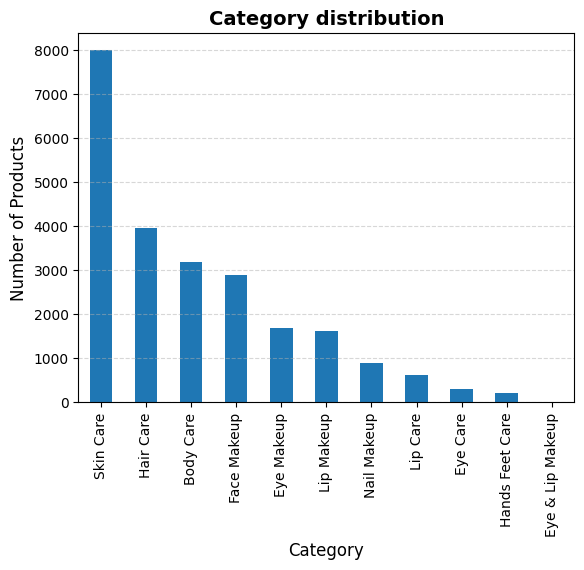

In [9]:
category_distribution.plot(kind='bar')

plt.title('Category distribution', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Observations

Skin Care dominates Nykaa's product assortment, with approximately twice the number of products compared with the second-largest category, Hair Care.

Body Care follows Hair Care, while Face Makeup and Eye Makeup are also among the more highly represented categories.

#### 3.1.2. Subcategory Distribution

In [10]:
subcat_distribution = nykaa_df['sub_category'].value_counts()

In [11]:
subcategory_distribution = subcat_distribution.sort_values(ascending=False)

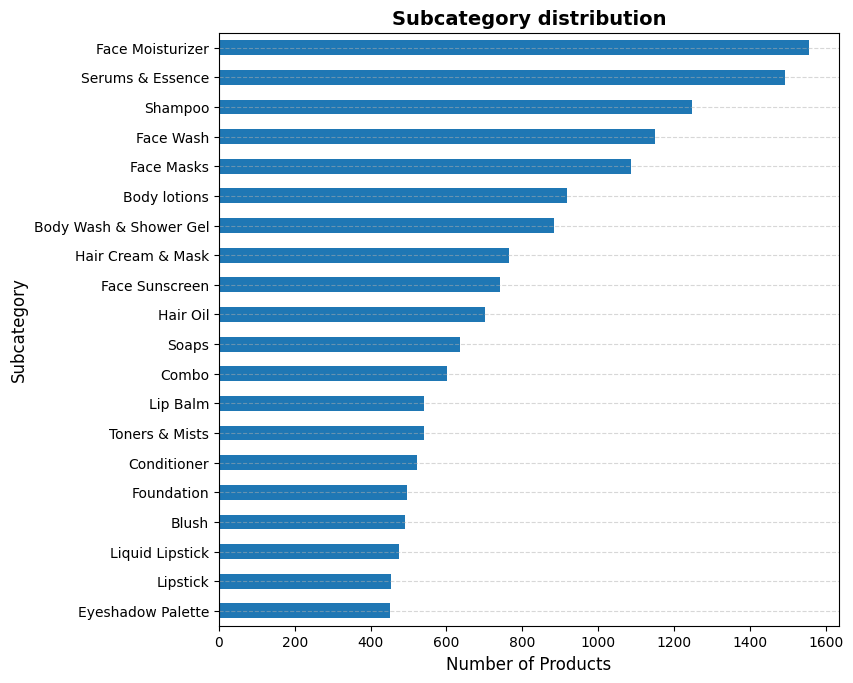

In [12]:
subcategory_distribution.head(20).plot(
    kind='barh', 
    figsize=(8, len(subcategory_distribution) * 0.1))

plt.gca().invert_yaxis()

plt.title('Subcategory distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('Subcategory', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Observations

Face Moisturizer and Serum are the leading subcategories in Nykaa's product assortment, followed by Shampoo, Face Wash, and Face Masks.

The strong representation of these subcategories reflects the substantial presence of skincare and haircare essentials within Nykaa's product assortment.

### 3.2. Brand Analysis

#### Business Question

How is Nykaa's product assortment distributed across brands?

#### Purpose

Identify brands with the largest product assortment and examine the distribution of products across leading brands.

In [13]:
brands_product_count = nykaa_df['brand'].value_counts()

In [14]:
brand_products = brands_product_count[brands_product_count.index != 'Unknown'].sort_values(ascending=False)

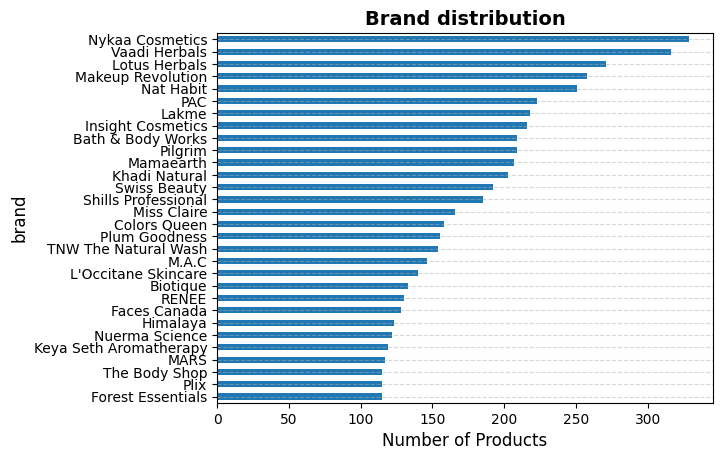

In [15]:
brand_products.head(30).plot(
    kind='barh')

plt.gca().invert_yaxis()

plt.title('Brand distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('brand', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Observations

- Nykaa Cosmetics has the largest product assortment in the dataset, making it the most represented brand.
- The top-ranked brands have relatively similar product counts, indicating that the product assortment is distributed across multiple leading brands rather than being dominated by a single brand.
- The leading brands include Nykaa's private label, established Indian brands, and international cosmetic brands, reflecting a diverse brand mix on the platform.

### 3.3. Price Analysis

#### Business Question

How are products distributed across different price ranges?

#### Purpose

Understand the pricing structure of products available on Nykaa.

#### 3.3.1. Price Distribution

A price range column is created to group products into different price segments. The number of products in each price range is then calculated and visualized to understand the overall pricing distribution.

In [16]:
print(nykaa_df['original_price'].describe())

count     23375.000000
mean       1267.680599
std        2963.933610
min          10.000000
25%         356.000000
50%         625.000000
75%        1350.000000
max      174500.000000
Name: original_price, dtype: float64


In [17]:
bins = [-1, 499, 1499, 2999, float('inf')]
labels = [
    'Budget', 
    'Mid-range', 
    'Premium', 
    'Luxury', 
]
legend_details = ['< ₹500', '₹500-₹1500', '₹1500-₹3000', '> ₹3000']
nykaa_df['price_range'] = pd.cut(nykaa_df['original_price'], bins=bins, labels=labels)

In [18]:
price_distribution = nykaa_df['price_range'].value_counts().sort_index()
price_distribution

price_range
Budget       9670
Mid-range    8408
Premium      3333
Luxury       1964
Name: count, dtype: int64

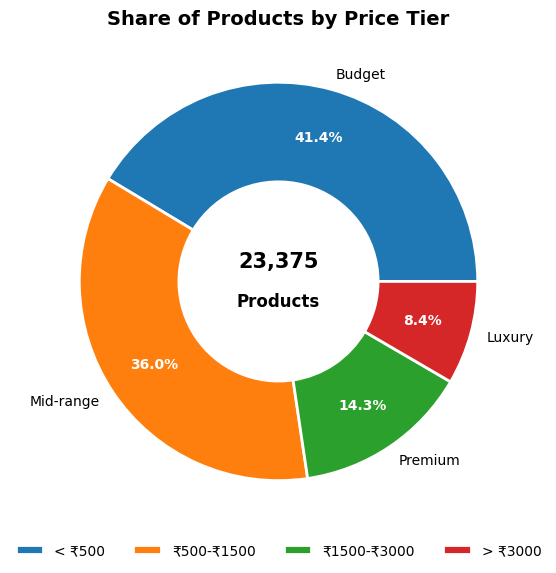

In [19]:
total_value = sum(price_distribution)
fig, ax = plt.subplots(figsize=(6, 6.5), facecolor='white')

wedges, texts, autotexts = plt.pie(
    price_distribution,
    labels=labels,
    autopct='%1.1f%%',
    labeldistance=1.08,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=10, weight="medium")

ax.text(
    0, 0.1, 
    f'{total_value:,}', 
    ha='center', va='center', 
    fontsize=15, fontweight='bold', 
    color='black'
)
ax.text(
    0, -.1, 
    f'Products', 
    ha='center', va='center', 
    fontsize=12, fontweight='bold', 
    color='black'
)

ax.legend(
    wedges, 
    legend_details,
    loc="upper center",         
    bbox_to_anchor=(0.5, -0.001), 
    ncol=4,                     
    frameon=False,              
    columnspacing=2.0           
)


plt.title('Share of Products by Price Tier', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()

#### Observations

Budget and Mid-range products together account for approximately 77% of Nykaa's product catalog, indicating a strong presence of affordable and mid-priced beauty products.

Premium products account for approximately 14.3%, while Luxury products account for approximately 8.4% of the catalog, representing smaller portions of the overall assortment.


#### 3.3.2. Original vs Discounted Price

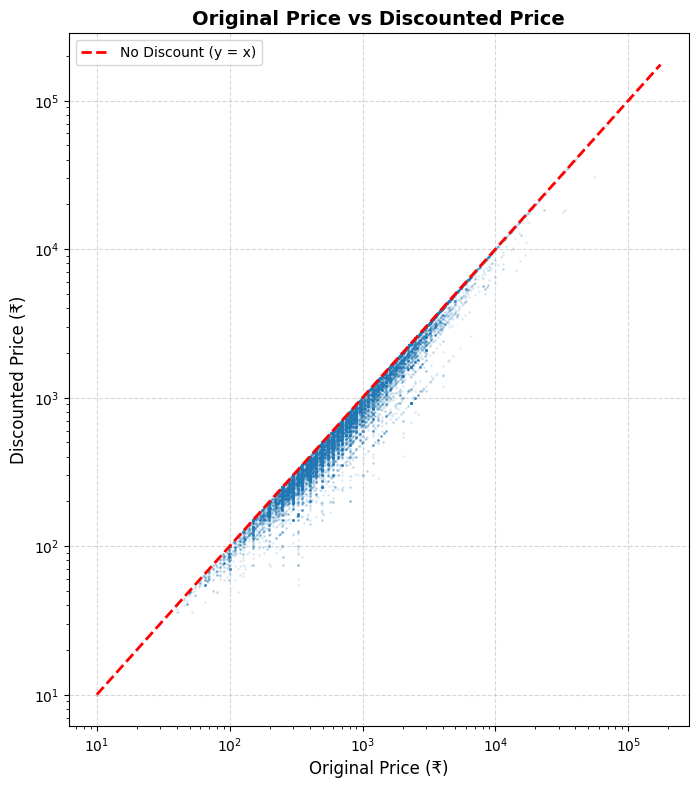

In [20]:
plt.figure(figsize=(8 , 9))
plt.scatter(
    nykaa_df['original_price'],
    nykaa_df['discounted_price'],
    s=1,
    alpha=0.1
)

# Log scales
plt.xscale('log')
plt.yscale('log')

# Reference line: y = x (No Discount)
min_price = nykaa_df['original_price'].min()
max_price = nykaa_df['original_price'].max()

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color='red',
    linestyle='--',
    linewidth=2,
    label='No Discount (y = x)'
)

plt.title('Original Price vs Discounted Price', fontsize=14, fontweight='bold')
plt.xlabel('Original Price (₹)', fontsize=12)
plt.ylabel('Discounted Price (₹)', fontsize=12)

plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

#### Observations

Most products in the lower-priced and luxury segments are listed at their original prices.

Products in the mid-range segment show a greater presence of discounted prices, although the discounts are generally modest.

### 3.4. Discount Analysis

#### Business Question

How are discounts distributed across products?

#### Purpose

Understand the distribution of discounts across Nykaa's product catalog.

#### 3.4.1 Discount percentage distribution

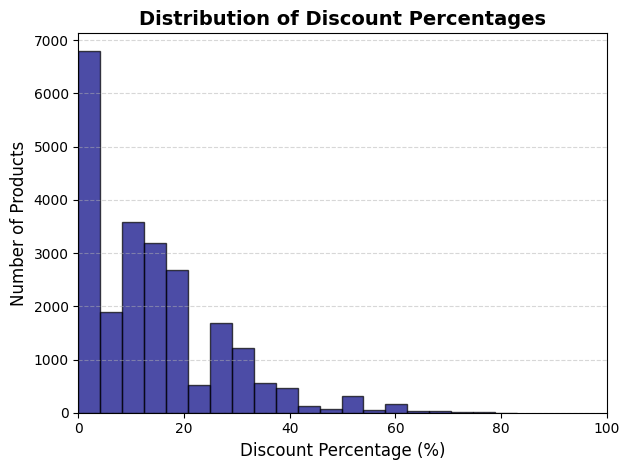

In [21]:
plt.hist(nykaa_df['discount_percent'].dropna(), bins=20, color='navy', edgecolor='black', alpha=0.7)

plt.title('Distribution of Discount Percentages', fontsize=14, fontweight='bold')
plt.xlabel('Discount Percentage (%)', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

#### Observations

- The discount percentage distribution is right-skewed, with most products having relatively low discount percentages.
- A large proportion of products have discounts below 4%.
- As the discount percentage increases, the number of products generally decreases.
- Products with discounts above 80% are very rare in the dataset.

#### 3.4.2 Discount tiers

In [22]:
bins = [-1, 0, 19, 39, 100]
labels = [
    'No discount \n (0%)',
    'Low Discount \n (1-19%)',
    'Medium Discount \n (20-39%)',
    'High Discount \n (40-100%)'
]
nykaa_df['discount_tier'] = pd.cut(nykaa_df['discount_percent'], bins=bins, labels=labels)

discount_tier_distribution = nykaa_df['discount_tier'].value_counts().sort_index()
discount_tier_distribution


discount_tier
No discount \n (0%)            6321
Low Discount \n (1-19%)        9901
Medium Discount \n (20-39%)    5942
High Discount \n (40-100%)     1211
Name: count, dtype: int64

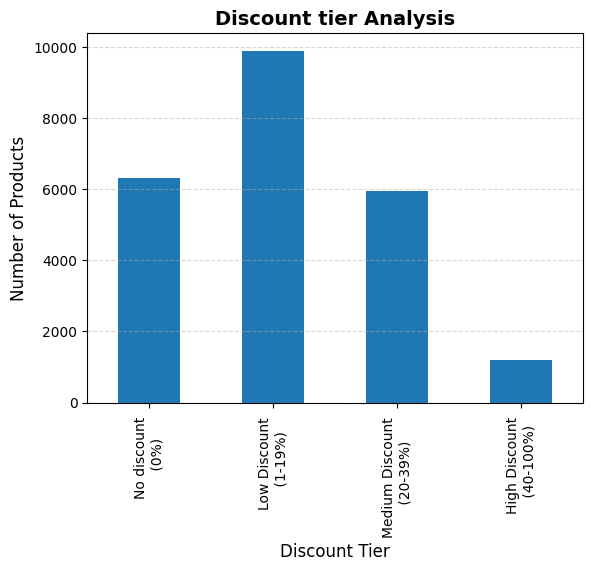

In [23]:
discount_tier_distribution.plot(kind='bar')

plt.title('Discount tier Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Discount Tier', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

#### Observations

The Low Discount tier contains the largest number of products, with approximately 10,000 products.

Around 6,000 products are listed without a discount, while products in the High Discount tier represent a relatively small portion of the catalog.

### 3.5. Customer Rating Analysis

#### Business Question

How are customer ratings distributed across products?

#### Purpose

Understand the overall rating distribution of products listed on Nykaa.

#### 3.5.1 Rating Distribution

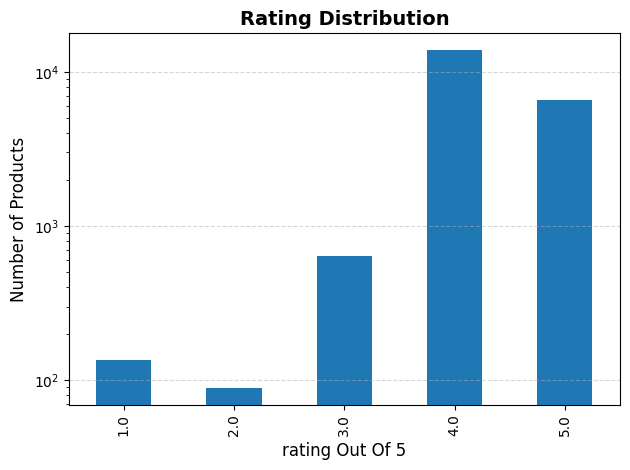

In [24]:
rating_distribution = nykaa_df['rating_out_of_5'].value_counts()
rating_distribution = rating_distribution.sort_index()

rating_distribution.plot(kind='bar')
plt.yscale('log')

plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('rating Out Of 5', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

#### Observations

Rating information is not available for all products in the dataset.

Among products with available ratings, approximately 95% have ratings between 4 and 5 stars, while low-rated products represent only a small proportion of rated products.

#### 3.5.2 Rating count distribution

In [25]:
nykaa_df['rating_count'].describe()

count    2.123700e+04
mean     3.326762e+04
std      3.819066e+05
min      1.000000e+00
25%      1.200000e+01
50%      9.300000e+01
75%      9.830000e+02
max      1.116496e+07
Name: rating_count, dtype: float64

In [26]:
rate_count_col = 'rating_count'
nykaa_df[rate_count_col] =  pd.to_numeric(nykaa_df[rate_count_col].replace(r'^\s*$', np.nan, regex=True), errors='coerce')

nykaa_df[rate_count_col] = nykaa_df[rate_count_col].fillna(-1)

bins = [-2, 0, 100, 500, 1000 , 5000 ,10000, float('inf') ]
labels = [
    'Not Available',
    '1-100',
    '101-500',
    '501-1000',
    '1001-5000',
    '5001-10000',
    '>10000'
]
nykaa_df['rating_count_group'] = pd.cut(nykaa_df['rating_count'], bins=bins, labels=labels)

rating_count_distribution = nykaa_df['rating_count_group'].value_counts().sort_index()
rating_count_distribution


rating_count_group
Not Available     2138
1-100            10826
101-500           3732
501-1000          1406
1001-5000         2476
5001-10000         673
>10000            2124
Name: count, dtype: int64

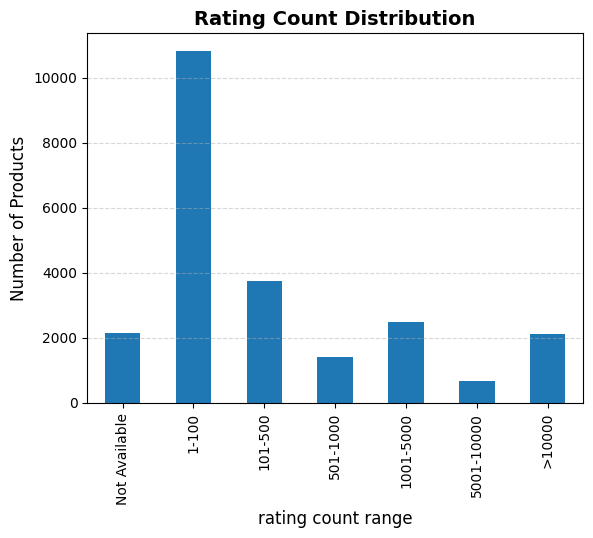

In [27]:
rating_count_distribution.plot(kind='bar')

plt.title('Rating Count Distribution', fontsize=14, fontweight='bold')
plt.xlabel('rating count range', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Observations

Rating count information is unavailable for a portion of the products in the dataset.

Among products with available rating counts, most products have fewer than 100 customer ratings, while a smaller number of products have substantially higher rating counts.

### 3.6. Customer Engagement Analysis

#### Business Question

Which brands and categories have the highest customer engagement based on rating counts?

#### Purpose

Compare customer engagement across brands, categories, and subcategories using rating counts as a proxy.

#### 3.6.1 Rating count by brand

In [28]:
rating_count_per_brand = nykaa_df.groupby('brand')[rate_count_col].sum()

In [29]:
rating_count_per_brand = rating_count_per_brand.sort_values(ascending = False)

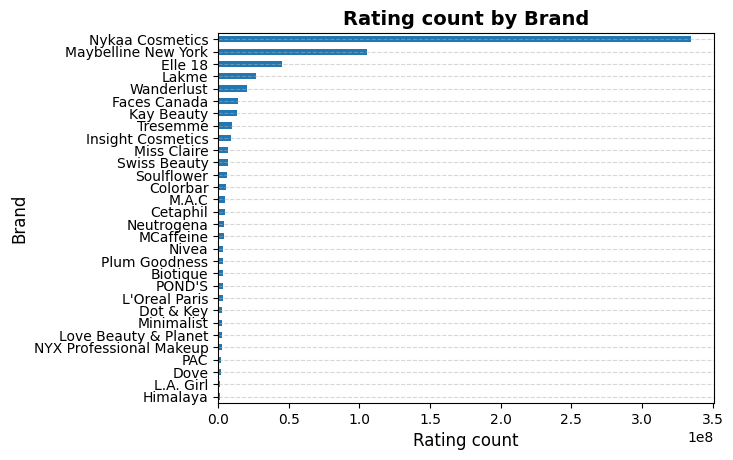

In [30]:
rating_count_per_brand.head(30).plot(kind='barh')

plt.gca().invert_yaxis()

plt.title('Rating count by Brand', fontsize=14, fontweight='bold')
plt.xlabel('Rating count', fontsize=12)
plt.ylabel('Brand', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Observations

- Nykaa Cosmetics has the largest product assortment in the dataset and also records the highest total rating count among the brands analyzed.
- This indicates that Nykaa Cosmetics has both a broad product presence and a high volume of customer ratings in the collected dataset.

#### 3.6.2 Rating count by category

In [31]:
rating_count_per_category = nykaa_df.groupby('category')[rate_count_col].sum()

In [32]:
rating_count_per_category = rating_count_per_category.sort_values(ascending = False)

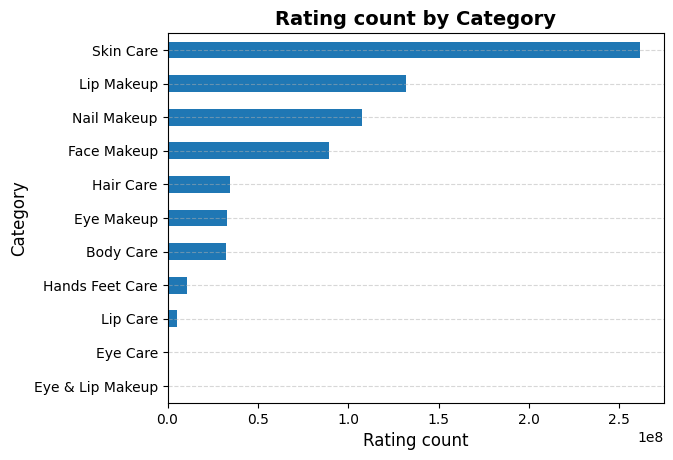

In [33]:
rating_count_per_category.plot(kind='barh')

plt.gca().invert_yaxis()

plt.title('Rating count by Category', fontsize=14, fontweight='bold')
plt.xlabel('Rating count', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Observations

- Skin Care has the highest total rating count, with more than 261 million ratings, making it the category with the highest observed customer engagement proxy in the dataset.
- Lip Makeup, Nail Makeup, and Face Makeup follow Skin Care in terms of total rating count, indicating substantial customer interest in these makeup categories.
- Categories with larger product assortments generally tend to have higher total rating counts. However, this comparison does not establish a statistical relationship between assortment size and customer engagement.

#### 3.6.3 Rating count by Subcategory

In [34]:
rating_count_per_subcategory = nykaa_df[nykaa_df['sub_category'] != 'Combo'].groupby('sub_category')[rate_count_col].sum()

In [35]:
rating_count_per_subcategory = rating_count_per_subcategory.sort_values(ascending = False)

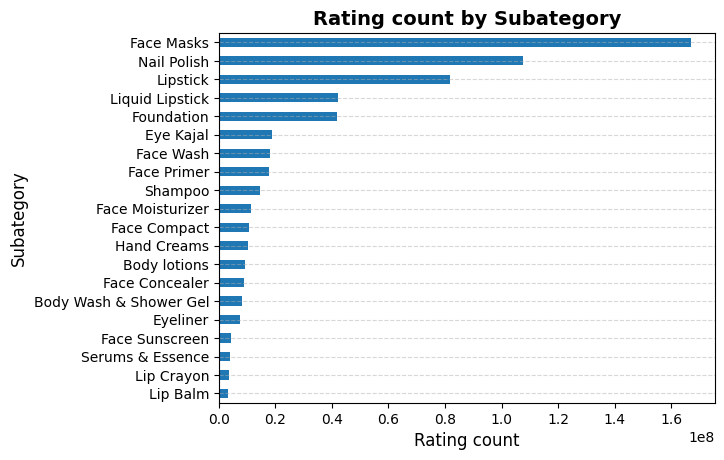

In [36]:
rating_count_per_subcategory.head(20).plot(kind='barh')

plt.gca().invert_yaxis()

plt.title('Rating count by Subategory', fontsize=14, fontweight='bold')
plt.xlabel('Rating count', fontsize=12)
plt.ylabel('Subategory', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Observations

- Face Masks have the highest total rating count, with more than 167 million customer ratings, making them the most highly rated subcategory by rating volume in the dataset.
- Nail Polish and Lipstick rank second and third, followed by Liquid Lipstick and Foundation, indicating substantial rating volumes for several color-cosmetics subcategories.
- Everyday-use skincare products such as Face Wash, Face Moisturizer, and Face Sunscreen also record substantial rating volumes, highlighting their strong presence in the dataset.
- Haircare essentials, particularly Shampoo, have higher total rating counts than other haircare subcategories such as Hair Oil, Hair Serum, and Conditioner.
- Specialized products such as Eye Primer, Lip Plumper, Bath Salts, Hand & Foot Masks, and Eyeshadow have comparatively lower rating volumes in the dataset.
- Face Masks do not necessarily have the largest product assortment, yet they have the highest total rating count. This indicates that rating volume is influenced by factors beyond the number of products available within a subcategory.

### 3.7. Relationship Analysis

#### Business Question

What relationships exist between price, discounts, ratings, and customer engagement?

#### Purpose

Identify patterns and associations between key product attributes such as price, discount percentage, rating, and rating count.


#### 3.7.1 Price vs Rating Count

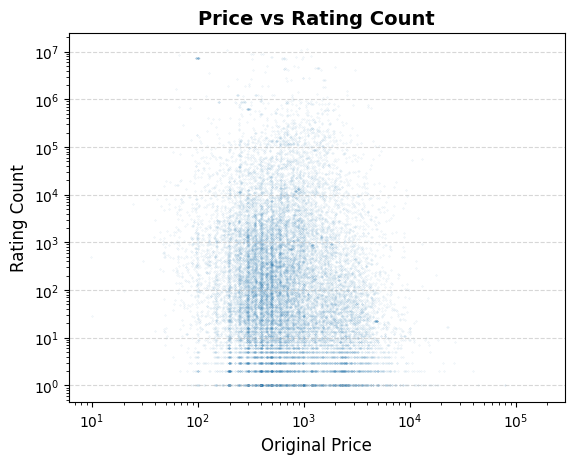

In [37]:
price_jitter = nykaa_df['original_price'] + np.random.normal(
    loc=0,
    scale=nykaa_df['original_price'] * 0.02
)
plt.scatter(price_jitter,nykaa_df['rating_count'],s=.05,alpha=0.2)

plt.xscale('log')
plt.yscale('log')

plt.title('Price vs Rating Count', fontsize=14, fontweight='bold')
plt.xlabel('Original Price', fontsize=12)
plt.ylabel('Rating Count', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Observation

Most products are concentrated between ₹200 and ₹1,500.

Customer rating counts vary considerably across different price ranges, indicating that product price alone does not appear to strongly determine rating count in the dataset.

#### 3.7.2 Discount tier vs Rating Count

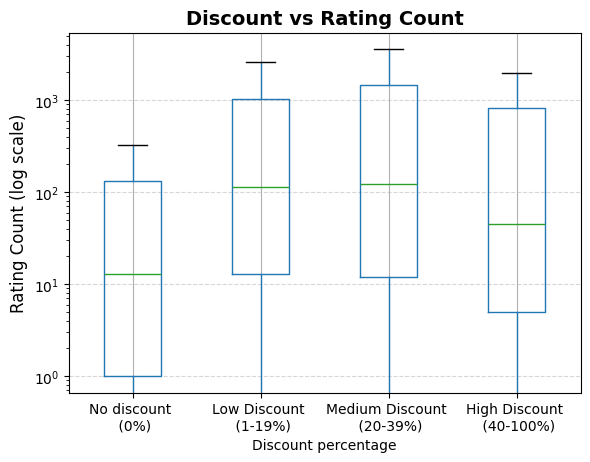

In [38]:
ax = nykaa_df.boxplot(column='rating_count', by='discount_tier',showfliers=False)

plt.yscale('log')

plt.title('Discount vs Rating Count', fontsize=14, fontweight='bold')
plt.xlabel('Discount percentage', fontsize=10)
plt.ylabel('Rating Count (log scale)', fontsize=12)

plt.suptitle('') 

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Observations

Products in the Medium Discount tier (20–39%) have the highest median rating count among the discount tiers.

Low-discount products also show relatively high median rating counts, while products with no discount have the lowest typical rating count.

This suggests that products with moderate discounts have higher typical rating volumes in the collected dataset, although this analysis does not establish that discounts directly cause higher customer engagement.

#### 3.7.3. Price vs Discount

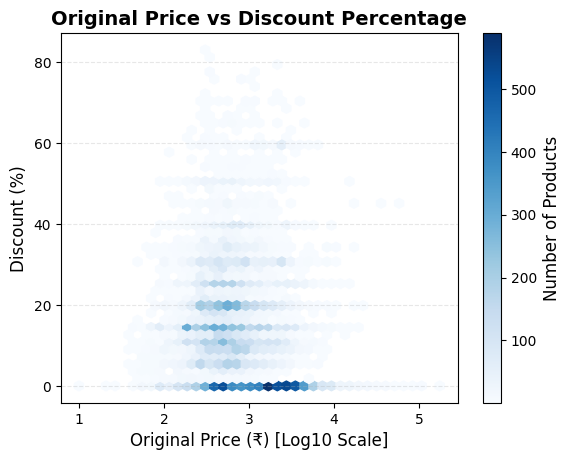

In [39]:
hb = plt.hexbin(
    np.log10(nykaa_df['original_price']),
    nykaa_df['discount_percent'],
    gridsize=40,  # Number of hexagons along the x-axis
    cmap='Blues', 
    mincnt=1,  # Do not plot empty hexagons
)

cb = plt.colorbar(hb)
cb.set_label('Number of Products', fontsize=12)

plt.title('Original Price vs Discount Percentage', fontsize=14, fontweight='bold')
plt.xlabel('Original Price (₹) [Log10 Scale]', fontsize=12)
plt.ylabel('Discount (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


#### Observations

- Most products are concentrated in the mid-price range, approximately ₹250–₹3,000, with product density declining toward both lower and higher price points.
- The largest concentration occurs at 0% discount, indicating that many products are listed without a discount.
- Discounts between approximately 10% and 30% are also common across the dominant price range.
- Products with very high discounts (above 50%) are comparatively rare.
- There is no strong visible relationship between original price and discount percentage. Products across different price ranges receive both low and moderate discounts.
- Product density becomes much lower above approximately ₹10,000, indicating that higher-priced products represent a relatively small portion of the catalog.

## 4. Conclusion

The exploratory analysis of the Nykaa product dataset provides an overview of the platform's product assortment, pricing, discount patterns, customer ratings, and rating volumes.

The analysis shows that **Skin Care has the largest product assortment**, while Face Moisturizer and Serum are among the leading subcategories. Budget and mid-range products account for the majority of the catalog, indicating a strong presence of affordable and moderately priced products.

Discounts are generally concentrated in the lower ranges, with high discounts representing a relatively small portion of the catalog. Among products with available ratings, most are rated between 4 and 5 stars, while rating counts vary considerably across products.

The customer engagement analysis shows that **Skin Care has the highest total rating count**, while Face Masks have the highest rating volume among subcategories. The relationship analysis also indicates that product price does not appear to strongly determine rating count, and products with moderate discounts show higher typical rating volumes in the collected dataset.

Overall, the EDA provides a clear understanding of Nykaa's product assortment and customer rating patterns and establishes a foundation for the subsequent **SQL business analysis**.
